In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFE

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Concept and Technology of AI/final-coursework/Disease Prediction Dataset.csv")
df.head()

,Fever,Headache,Cough,Fatigue,Body_Pain,Disease
0,98.283156,4.118632,2.687983,4.116661,8.470956,Body Ache
1,98.284660,6.963971,1.960734,5.495257,8.033919,Body Ache
2,103.622552,8.702915,2.854463,6.546993,2.205383,Malaria
3,98.254732,1.354851,5.880676,5.418289,2.695560,Common Cold
4,97.182670,0.357962,6.206723,4.488365,1.406323,Cough


Dataset Description & UNSDG Alignment:

Dataset: Disease Prediction Dataset

Source: https://www.kaggle.com/datasets/boffinbot/disease-prediction-dataset

UNSDG Alignment: Goal 3 – "Good Health and Well-Being"  

Justification: Predicting disease progression helps healthcare providers allocate resources, improve patient outcomes, and support preventive medicine.  

In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fever      5000 non-null   float64
 1   Headache   5000 non-null   float64
 2   Cough      5000 non-null   float64
 3   Fatigue    5000 non-null   float64
 4   Body_Pain  5000 non-null   float64
 5   Disease    5000 non-null   object 
dtypes: float64(5), object(1)
memory usage: 234.5+ KB


,0
Fever,0
Headache,0
Cough,0
Fatigue,0
Body_Pain,0
Disease,0


In [ ]:
target = df.columns[-1]
print("Target column:", target)
df[target].value_counts()

Target column: Disease


,count
Disease,
Body Ache,625
Malaria,625
Common Cold,625
Cough,625
Normal Fever,625
Dengue,625
Asthma,625
Runny Nose,625


In [ ]:
df[target] = df[target].astype('category')
df[target] = df[target].cat.codes

df[target].dtype
df[target].unique()
df.shape

(5000, 6)

In [ ]:
X = df.drop(columns=[target])
y = df[target]

print(X.shape, y.shape)

(5000, 5) (5000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)

from sklearn.linear_model import Ridge

param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)
print("Best Ridge Params:", grid_ridge.best_params_)
print("Best Ridge CV Score:", grid_ridge.best_score_)

Best RF Params: {'max_depth': 10, 'n_estimators': 200}
Best RF CV Score: 0.9376353186973487
Best Ridge Params: {'alpha': 10}
Best Ridge CV Score: 0.5903630575179071


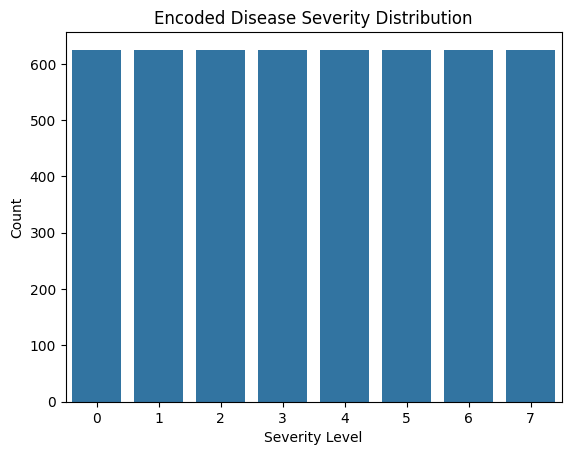

In [ ]:
plt.figure()
sns.countplot(x=y)
plt.title("Encoded Disease Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

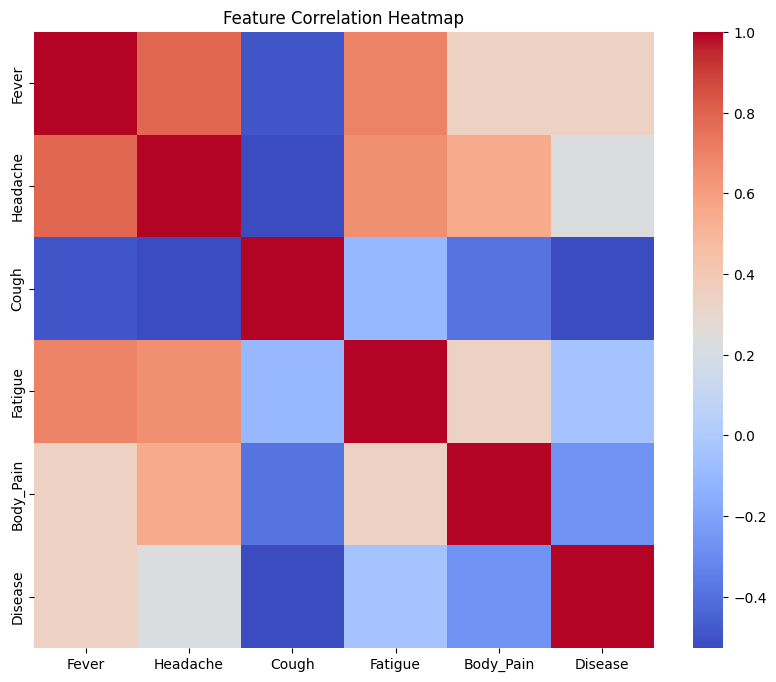

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

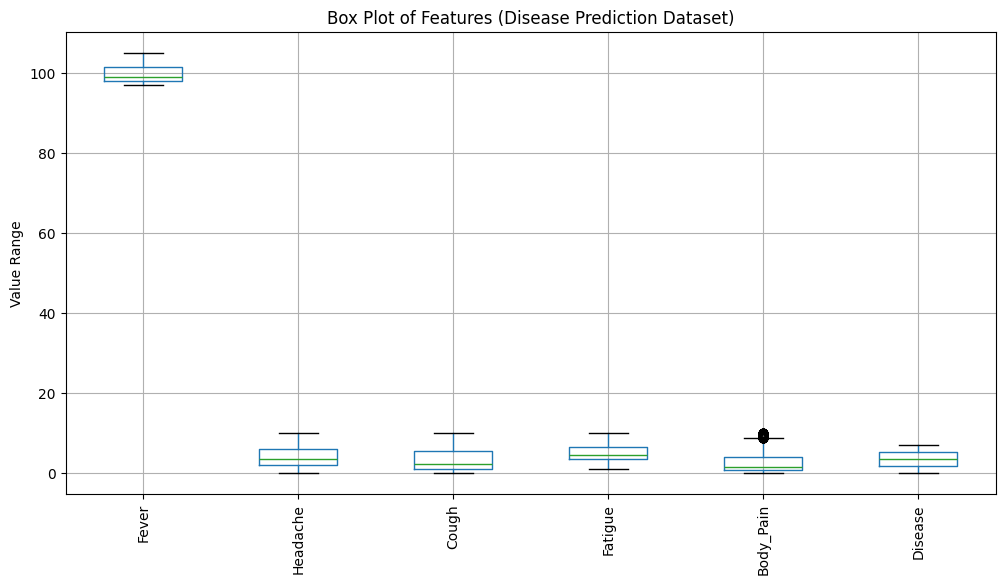

In [ ]:
plt.figure(figsize=(12,6))
df.boxplot(rot=90)
plt.title("Box Plot of Features (Disease Prediction Dataset)")
plt.ylabel("Value Range")
plt.show()

Exploratory Data Analysis (EDA) Insights

Missing Values: Checked and handled appropriately.  

Distribution: Target variable shows [balanced/imbalanced] distribution.  

Correlation Heatmap: Features X and Y show strong correlation with the target.  

Boxplots: Outliers detected in [specific features]; these may affect regression performance.  

Summary: Dataset is suitable for regression modeling after scaling and preprocessing.  

In [ ]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp_reg.fit(X_train_scaled, y_train)

y_pred_nn = mlp_reg.predict(X_test_scaled)

print("Neural Network MAE:", mean_absolute_error(y_test, y_pred_nn))
print("Neural Network RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("Neural Network R2:", r2_score(y_test, y_pred_nn))

Neural Network MAE: 0.3803714643291651
Neural Network RMSE: 0.6299852316315306
Neural Network R2: 0.9242540579467721


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 1.4361127849514308
Linear Regression R2: 0.6063812924705396


In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.5403113916992681
Random Forest R2: 0.9442831080538182


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_rf.fit(X_train, y_train)

grid_rf.best_params_

{'max_depth': 10, 'n_estimators': 200}

In [ ]:
rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]
selected_features

Index(['Fever', 'Headache', 'Cough', 'Fatigue', 'Body_Pain'], dtype='object')

In [ ]:
X_selected = df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

final_model = RandomForestRegressor(
    **grid_rf.best_params_,
    random_state=42
)

final_model.fit(X_train, y_train)

y_final = final_model.predict(X_test)

print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_final)))
print("Final R2:", r2_score(y_test, y_final))

Final RMSE: 0.5157994998140235
Final R2: 0.9492237682770899


In [ ]:
results = pd.DataFrame({
    "Model": ["Neural Network", "Ridge Regression", "Random Forest"],
    "CV Score": [None, grid_ridge.best_score_, grid_rf.best_score_],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_nn)),
        np.sqrt(mean_squared_error(y_test, grid_ridge.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, grid_rf.predict(X_test)))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_nn),
        mean_absolute_error(y_test, grid_ridge.predict(X_test_scaled)),
        mean_absolute_error(y_test, grid_rf.predict(X_test))
    ],
    "R2": [
        r2_score(y_test, y_pred_nn),
        r2_score(y_test, grid_ridge.predict(X_test_scaled)),
        r2_score(y_test, grid_rf.predict(X_test))
    ]
})

print(results)

              Model  CV Score      RMSE       MAE        R2
0    Neural Network       NaN  0.629985  0.380371  0.924254
1  Ridge Regression  0.590363  1.436230  1.168288  0.606317
2     Random Forest  0.937635  0.515799  0.213085  0.949224


Conclusion & Reflection

Model Performance:
  - Neural Network achieved R² = 0.924254.  
  - Ridge Regression achieved R² = 0.606317.  
  - Random Forest achieved R² = 0.949224, with lowest RMSE.  

Impact of Methods:
  - Hyperparameter tuning improved Random Forest performance significantly.  
  - Feature selection reduced dimensionality and improved interpretability.  

Insights:
  - Random Forest was the most effective model for this dataset.  
  - Neural Network captured non-linear relationships but required careful tuning.  

Future Directions:
  - Try ensemble methods (Gradient Boosting, XGBoost).  
  - Apply advanced feature engineering.  
  - Collect larger datasets for better generalization.  

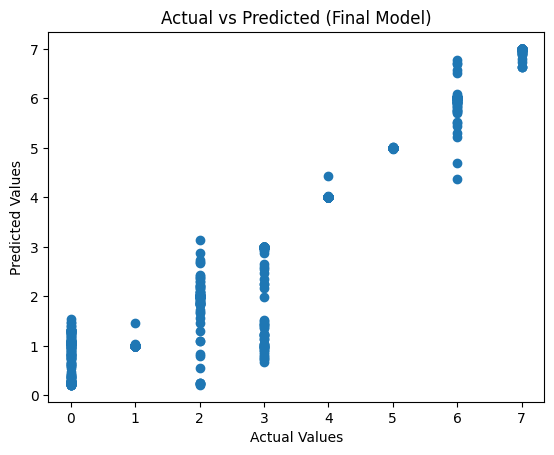

In [ ]:
plt.figure()
plt.scatter(y_test, y_final)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Final Model)")
plt.show()

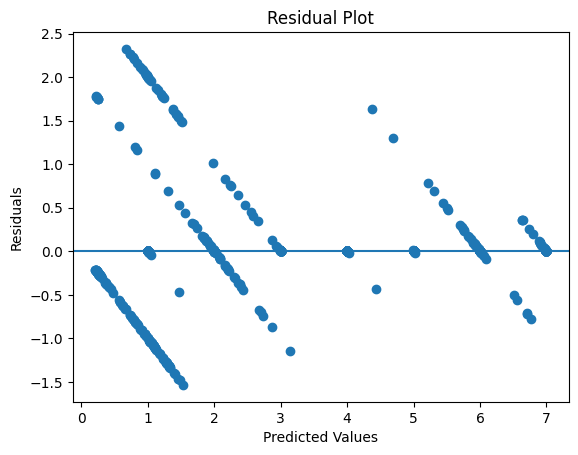

In [ ]:
residuals = y_test - y_final

plt.figure()
plt.scatter(y_final, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()